# DimeNet++ training-budget experiment

## Completed experiment

The 200-epoch training-budget experiment is complete. Under the original joint validation selection rule, epoch 200 is selected. Energy MAE increased by 11.07%, while force component MAE decreased by 26.56%. The result is a trade-off, not an improvement in every target. This report supersedes the 144-epoch interim snapshot.

## Controlled protocol

- Ethanol CCSD(T), unchanged Gold data: 889 training and 111 validation configurations.
- Seed 42; learning rate 0.0001; energy/force loss weights 1/100; unchanged architecture and batch size.
- One changed training factor: epoch budget, 100 to 200.
- Started from the same seeded initialization because the old checkpoint has no optimizer state. This is not an exact optimizer resume and is not an independent replicate.
- Checkpoint selection: minimum validation energy RMSE squared plus 100 times force RMSE squared.
- New selected epoch: 200. Budget completion alone does not establish convergence.
- Maximum metric difference over the first 100 epochs: 0.
- No test evaluation or test-derived correction was performed for this experiment.

## Validation results

Energy units: kcal/mol. Force units: kcal/mol/angstrom; Cartesian component metrics.
Positive reduction means a lower error; negative reduction means a higher error.

| Metric | Previous selected checkpoint | New selected checkpoint | Relative reduction |
|---|---:|---:|---:|
| energy_mae | 1.634226 | 1.815057 | -11.07% |
| energy_rmse | 1.749992 | 1.880484 | -7.46% |
| force_mae | 1.563769 | 1.148505 | +26.56% |
| force_rmse | 2.178289 | 1.581583 | +27.39% |

Weighted selection score: 477.556854 to 253.676836. Individual metrics need not all improve under a joint selection rule.

## Limitations and next step

This is one seed and one molecule. Shared-prefix runs are dependent. Validation was used for model selection, so these scores are not a fresh generalization estimate. Earlier test-error analysis informed possible follow-up work; do not present the old test set as an untouched new assessment. Repeat a fixed protocol with additional seeds and agree on a final evaluation protocol with the team.

## Reproduction

Training: `python -B -m ml.training.train_dimenet --config experiments/configs/dimenet_ethanol_lr1e4_200.yaml`

Run this only on dongxiao. The training runner deliberately refuses to overwrite an existing result directory. This command starts 200 epochs from scratch.

Analysis: `python build_budget_comparison.py --repo REPOSITORY --out OUTPUT_DIRECTORY`

The experiment reuses the existing runner, whose saved purpose field still says smoke test; this report describes the actual full-split training-budget comparison. Model weights stay local.



In [1]:
import json
from pathlib import Path
old = json.loads(Path('run_100_metrics.json').read_text())
new = json.loads(Path('run_200_metrics.json').read_text())
assert old['history'] == new['history'][:100]
assert old['selected_gold_indices'] == new['selected_gold_indices']
assert old['gold_sha256'] == new['gold_sha256']
def selected(run):
    return min(run['history'], key=lambda h:
        h['validation']['energy_rmse']**2 + 100*h['validation']['force_rmse']**2)
previous, current = selected(old), selected(new)
print('Selected epochs:', previous['epoch'], current['epoch'])
for metric, before in previous['validation'].items():
    after = current['validation'][metric]
    print(f'{metric}: {before:.6f} -> {after:.6f}; reduction = {100*(before-after)/before:+.2f}%')
print('First 100 epochs identical. No new test evaluation.')

Selected epochs: 100 200
energy_mae: 1.634226 -> 1.815057; reduction = -11.07%
energy_rmse: 1.749992 -> 1.880484; reduction = -7.46%
force_mae: 1.563769 -> 1.148505; reduction = +26.56%
force_rmse: 2.178289 -> 1.581583; reduction = +27.39%
First 100 epochs identical. No new test evaluation.


## Saved analysis output
The report below records the completed analysis; rerun the cell above to load it locally.
```json
{
  "scope": "Training-budget ablation; validation-only comparison",
  "old_best_epoch": 100,
  "new_best_epoch": 200,
  "old_validation": {
    "energy_mae": 1.634225703843005,
    "energy_rmse": 1.7499916430196756,
    "force_mae": 1.5637693169005005,
    "force_rmse": 2.1782891980364436
  },
  "new_validation": {
    "energy_mae": 1.815056636526778,
    "energy_rmse": 1.880483582170917,
    "force_mae": 1.1485051014148318,
    "force_rmse": 1.5815834405172682
  },
  "relative_reduction_percent": {
    "energy_mae": -11.065236108974137,
    "energy_rmse": -7.456717846153406,
    "force_mae": 26.555337222548353,
    "force_rmse": 27.39332123838555
  },
  "selection_score_old": 477.55685377886397,
  "selection_score_new": 253.67683643465827,
  "first_100_epochs_max_absolute_metric_difference": 0.0,
  "same_data_model_seed_optimizer": true,
  "test_evaluated": false,
  "gold_sha256": "8e6571e1c0f0ac5a4fbab8a3236c26abff0095f54772866ad6ffa7f525deb441",
  "new_checkpoint_sha256": "861ce3d11d8cf24fe79feb2e393c3738a37f9bff5bb206c5180674f72c221ba0"
}
```

## Training comparison
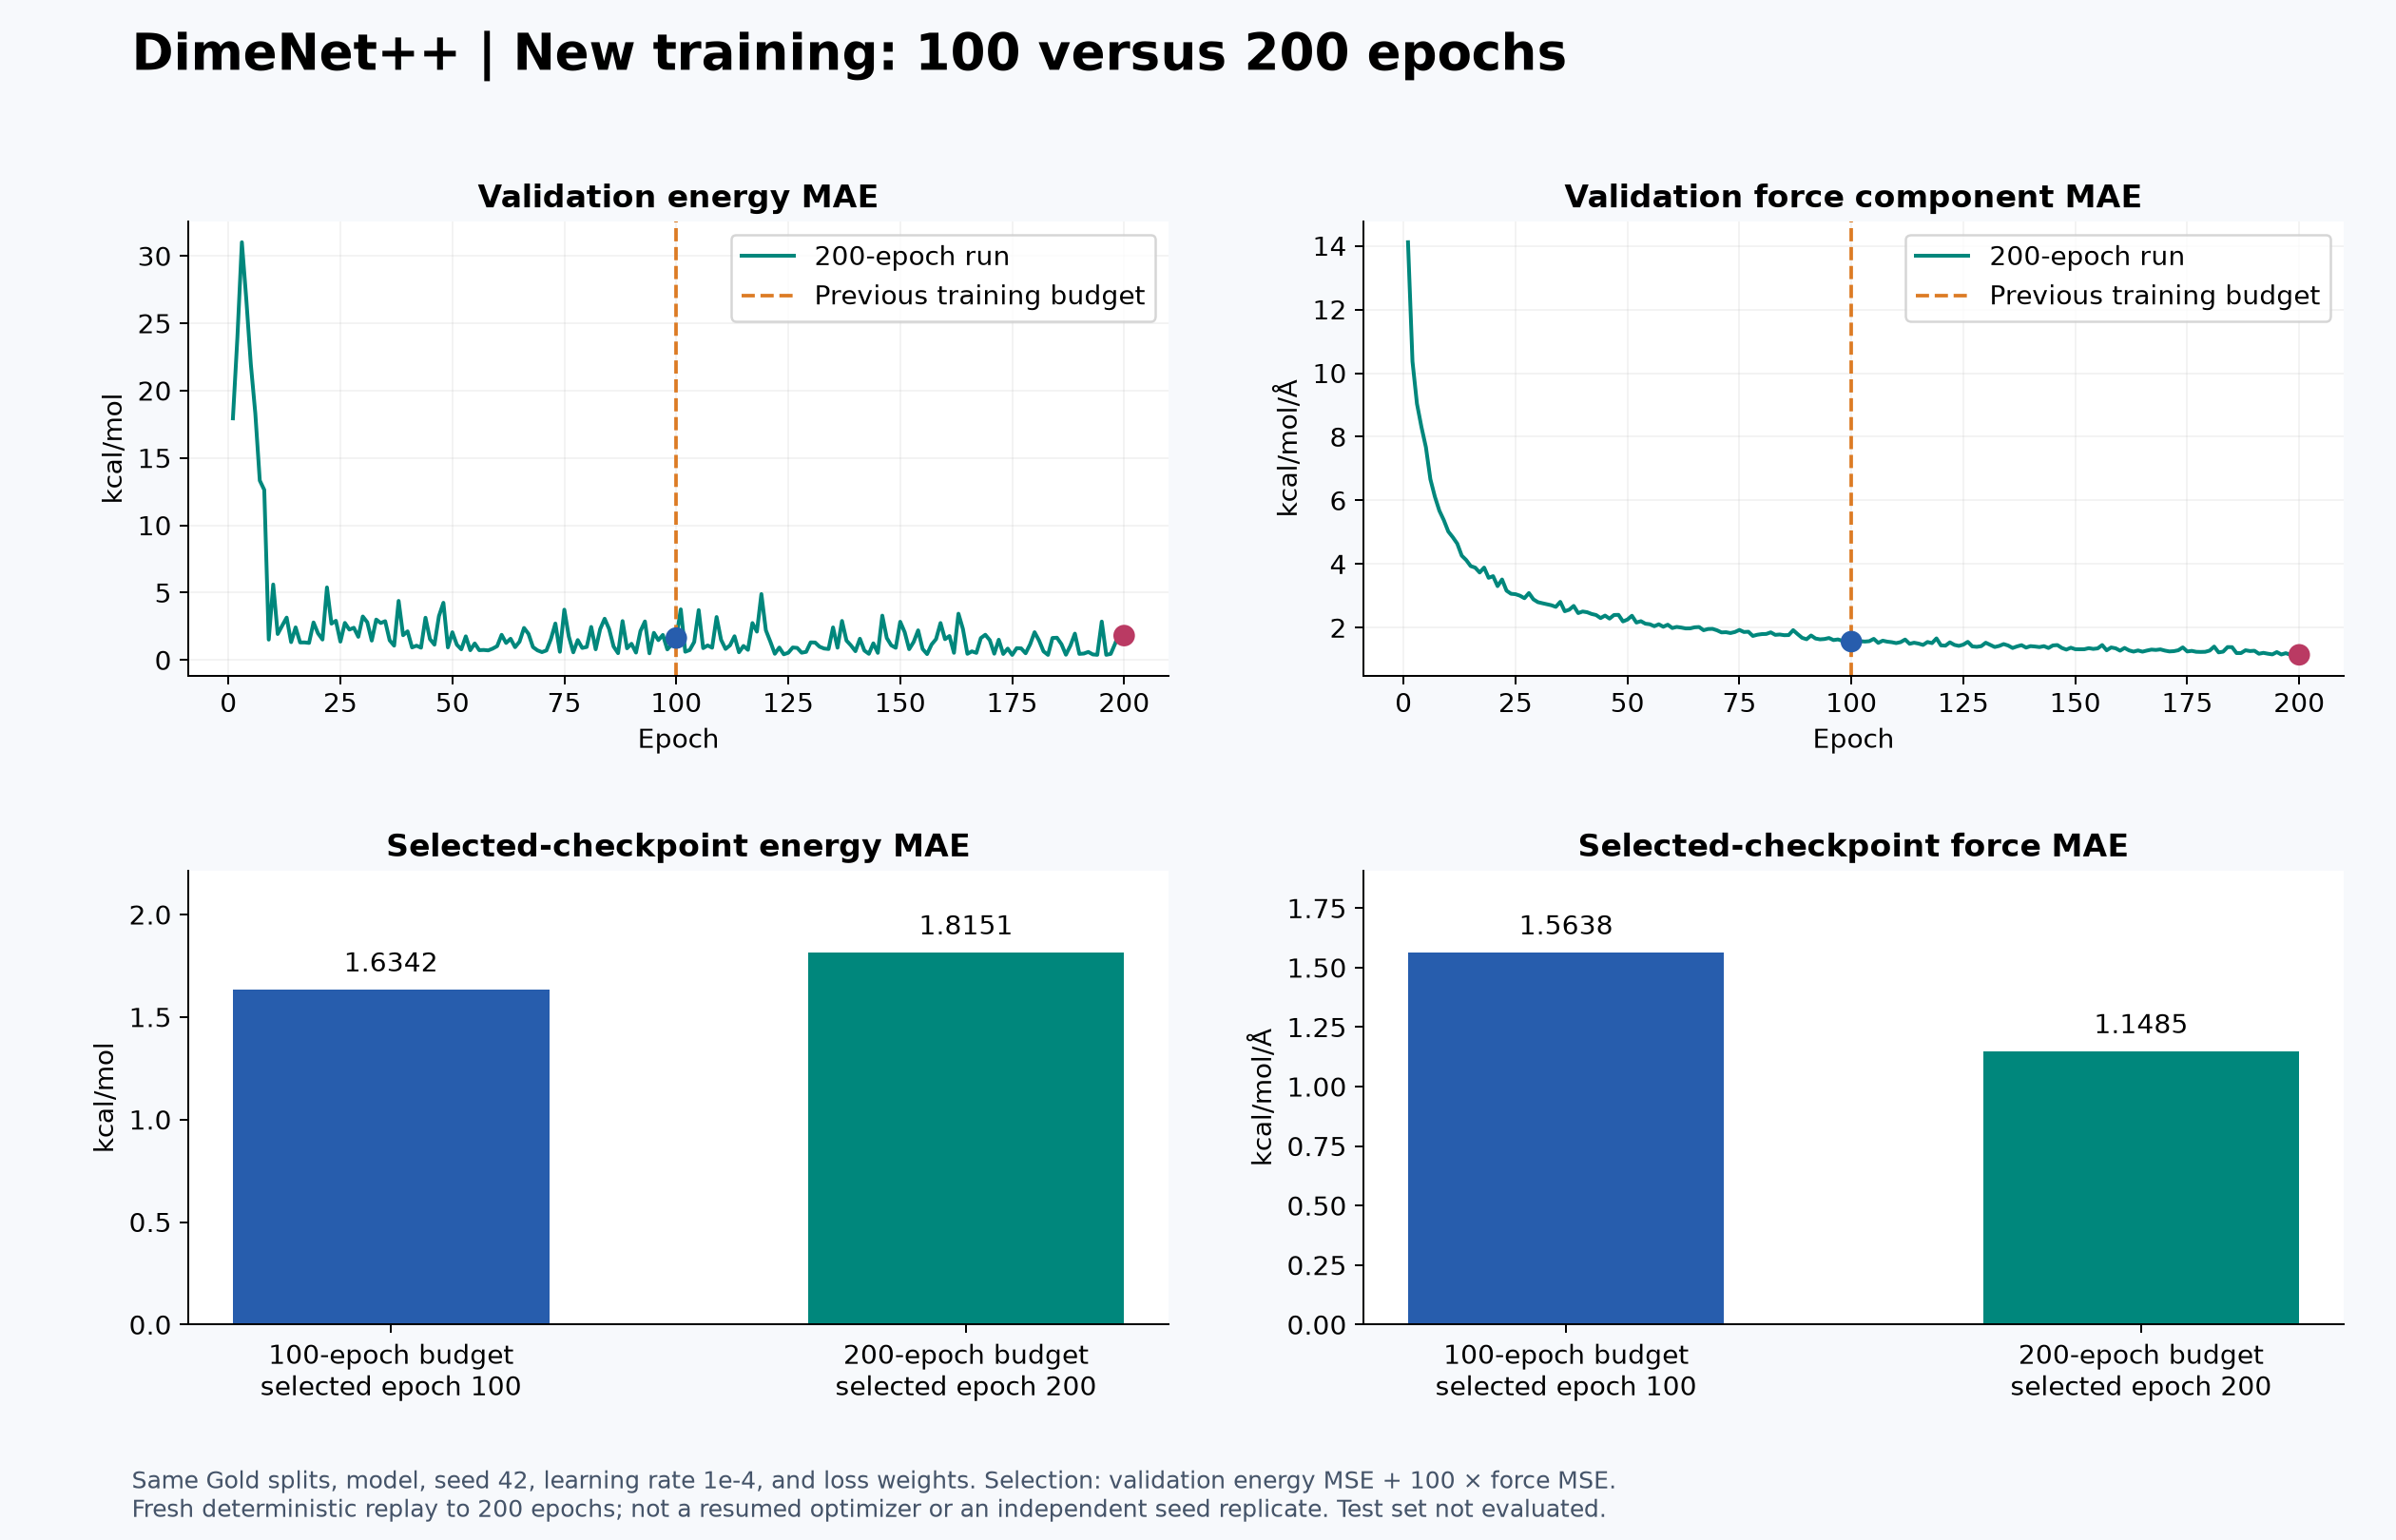